In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=5000)


x_train = pad_sequences(x_train, maxlen=100)
x_test = pad_sequences(x_test, maxlen=100)

Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7606 - loss: 0.4661
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9125 - loss: 0.2263
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9819 - loss: 0.0707


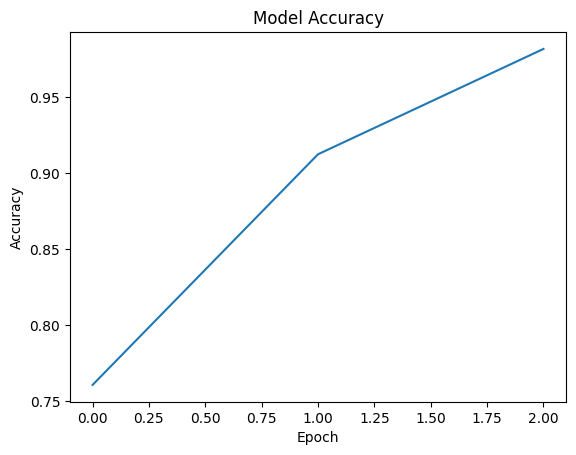

In [ ]:
model = Sequential()

model.add(Embedding(5000, 32, input_length=100))
model.add(Flatten())

model.add(Dense(32, activation='relu'))


model.add(Dense(1, activation='sigmoid'))


model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


history = model.fit(x_train,
          y_train,
          epochs=3,
          batch_size=64)


plt.plot(history.history['accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8250 - loss: 0.4830
Accuracy: 0.8250399827957153


In [ ]:
predictions = model.predict(x_test[:5])

print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
[[0.06104185]
 [0.9947943 ]
 [0.6164084 ]
 [0.07908236]
 [0.99852276]]
